# Spring of Code - Artificial Intelligence

## Week 05: Machine Learning

### Day 03: Univariate Linear Regression and Gradient Descent


# Univariate Linear Regression?

**Univariate Linear Regression** is a statistical method used to model the relationship between a single independent variable (feature) and a dependent variable (target) using a linear equation.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.linspace(0, 10, 200)

array([ 0.        ,  0.05025126,  0.10050251,  0.15075377,  0.20100503,
        0.25125628,  0.30150754,  0.35175879,  0.40201005,  0.45226131,
        0.50251256,  0.55276382,  0.60301508,  0.65326633,  0.70351759,
        0.75376884,  0.8040201 ,  0.85427136,  0.90452261,  0.95477387,
        1.00502513,  1.05527638,  1.10552764,  1.15577889,  1.20603015,
        1.25628141,  1.30653266,  1.35678392,  1.40703518,  1.45728643,
        1.50753769,  1.55778894,  1.6080402 ,  1.65829146,  1.70854271,
        1.75879397,  1.80904523,  1.85929648,  1.90954774,  1.95979899,
        2.01005025,  2.06030151,  2.11055276,  2.16080402,  2.21105528,
        2.26130653,  2.31155779,  2.36180905,  2.4120603 ,  2.46231156,
        2.51256281,  2.56281407,  2.61306533,  2.66331658,  2.71356784,
        2.7638191 ,  2.81407035,  2.86432161,  2.91457286,  2.96482412,
        3.01507538,  3.06532663,  3.11557789,  3.16582915,  3.2160804 ,
        3.26633166,  3.31658291,  3.36683417,  3.41708543,  3.46

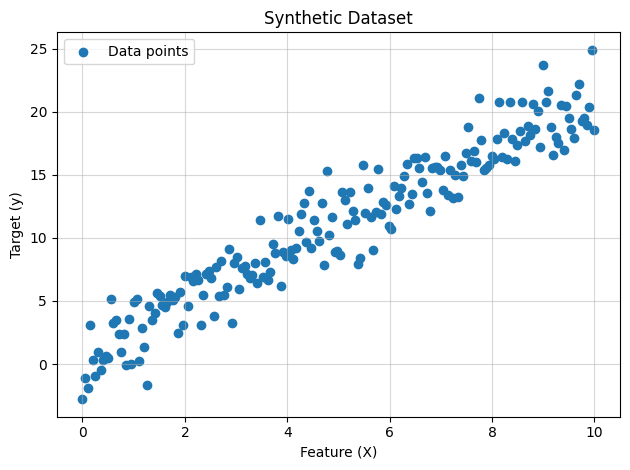

In [7]:
# Create a synthetic dataset with one feature and one target variable
X = np.linspace(0, 10, 200)
y = 2 * X + 1 + np.random.normal(0, 2, size=X.shape)
plt.scatter(X, y, label="Data points")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Synthetic Dataset")
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
# Size of the Dataset
print(f"Size of X: {X.size}, Size of y: {y.size}")
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Size of X: 200, Size of y: 200
Shape of X: (200,), Shape of y: (200,)


In [ ]:
# !pip install scikit-learn

In [30]:
# Let's split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")


Training set size: (160,), Testing set size: (40,)


In [26]:
import time
t = time.localtime()[5]
# print(f"Current time: {t}")

random = 20 + t
random

49

You can create Test and Train data with just python too.

In [24]:
import numpy as np
random_indices = np.random.choice(X.shape[0], size=200)
random_indices

array([114, 149, 176, 177,  79, 127,  26,  80, 177, 185,  91,  80,  15,
        63, 125, 185, 152,  69,  19, 187,  33, 171,  83, 144,  47, 113,
       122,  75,  45, 197, 172, 169, 135, 124,  19, 117,  37, 169, 173,
       186, 116,  53,  53,  33, 159,  56,  33, 163,   1, 147,  62, 123,
        78,  22,  90, 118,  50,   3,  44, 102, 146, 197,  34,  98,  27,
        48, 114, 158, 182,  55, 157, 127,  68,  91,  95, 112,  42, 100,
       161, 120,  32,  22, 140,  76,  89, 145,  33,  53, 195,   9,  62,
        67,  65, 188,   7, 131, 131, 134, 159,  71, 123,   3, 101,  92,
       131,  47,   1, 142, 157,  59, 151, 183, 166, 106,  73, 137,  62,
        52,  89,  58,  61,  28,  87, 164, 199, 108,  81, 164, 117, 109,
        36,   9,  13,  95,  83, 141, 160, 128, 172,  58,  51,  36, 136,
       139, 175, 158,  77, 167, 174,  84,  92, 186,  84,   9,  50, 106,
        68, 182,  24,  38,  25,  12, 130, 101,  56,  91,  38,  85,  91,
        80,  55,  43,   6,  21,  78, 184, 138, 144, 164, 166, 10

In [27]:
X = X[random_indices]
y = y[random_indices]

print(f"Random X", X[:5])
print(f"Random y", y[:5])

Random X [5.72864322 7.48743719 8.84422111 8.89447236 3.96984925]
Random y [12.0807803  16.74817494 18.59851286 20.02405462  8.57764647]


In [28]:
test_size = 0.2
index_split = int(X.shape[0] * test_size)

X_test = X[:index_split]
y_test = y[:index_split]

X_train = X[index_split:]
y_train = y[index_split:]

print(f"Training set size (X): {X_train.shape}, Testing set size (X): {X_test.shape}")
print(f"Training set size (y): {y_train.shape}, Testing set size (y): {y_test.shape}")


Training set size (X): (160,), Testing set size (X): (40,)
Training set size (y): (160,), Testing set size (y): (40,)


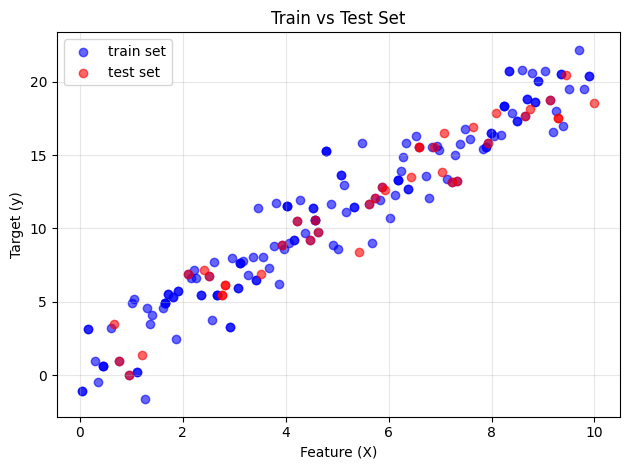

In [31]:
# Let's plot train set and test set
plt.scatter(X_train, y_train, c="blue", alpha=0.6, label="train set")
plt.scatter(X_test, y_test, c="red", alpha=0.6, label="test set")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Train vs Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Components of Linear Regression
## Hypothesis Function
The hypothesis function for univariate linear regression is a linear equation:
$$
f(x) = wx + b
$$

Where:
- **$f(x)$**: Hypothesis function (prediction)
- **$x$**: Input feature
- **$w$**: Weight (slope)
- **$b$**: Bias term (y-intercept)

**Goal of Linear Regression**: To find the best values of **$w$** and **$b$** that minimize the difference between predicted values and actual values.

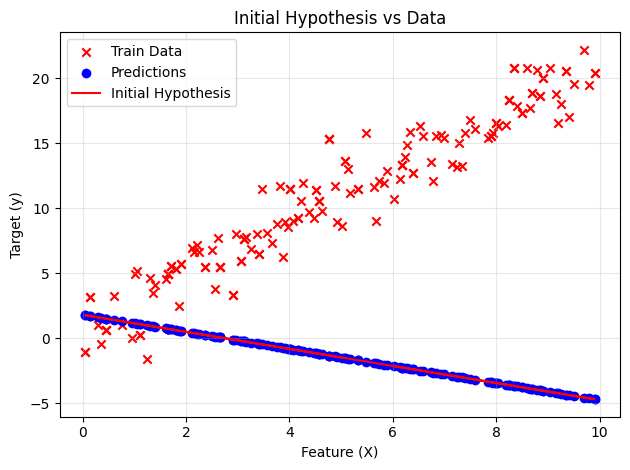

In [32]:
def hypothesis(X, w, b):
    predictions = []
    for x in X:
        pred = w * x + b
        predictions.append(pred)
    return np.array(predictions)


# Let's choose the initial values of w and b randomly
w, b = np.random.randn(), np.random.randn()


# Now based on these parameters, let's calculate the predictions
predictions = hypothesis(X_train, w, b)
plt.scatter(X_train, y_train, label="Train Data", marker='x', c = 'red')
plt.scatter(X_train, predictions, c = 'blue', label = 'Predictions', marker='o')
plt.plot(X_train, predictions, color='red', label="Initial Hypothesis")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Initial Hypothesis vs Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cost Function

We use the **Mean Squared Error (MSE)** to quantify this difference, and call it cost:

$$
\text{cost} = J(w_0, w_1) = (1/2m) × \sum_{i=1}^{m} (h(x^i) - y^i)^2
$$

Where:
- **$m$**: Number of training examples
- **$h(x^i)$**: Prediction for i-th example
- **$y^i$**: Actual value for i-th example


In [33]:
def compute_cost(predictions, actual):
    m = len(actual)
    loss = 0
    for i in range(m):
        loss = loss + (predictions[i] - actual[i]) ** 2
    cost = (1 / (2 * m)) * loss
    return cost

# Calculate the initial cost
initial_cost = compute_cost(predictions, y_train)
print(f"Current Parameters: w = {w:.4f}, b = {b:.4f}")
print(f"Initial Cost: {initial_cost:.4f}")

Current Parameters: w = -0.6564, b = 1.7895
Initial Cost: 104.8660


In [34]:
# Test with different parameters
test_params = [(0, 0), (1, 1), (2, 2), (3, 1)]
print(f"\nCost for different parameters:")
for w, b in test_params:
    pred = hypothesis(X_train, w, b)
    cost = compute_cost(pred, y_train)
    print(f"w = {w:.4f}, b = {b:.4f}\nCost = {cost:.4f}")



Cost for different parameters:
w = 0.0000, b = 0.0000
Cost = 76.3237
w = 1.0000, b = 1.0000
Cost = 17.8151
w = 2.0000, b = 2.0000
Cost = 1.8654
w = 3.0000, b = 1.0000
Cost = 16.7985


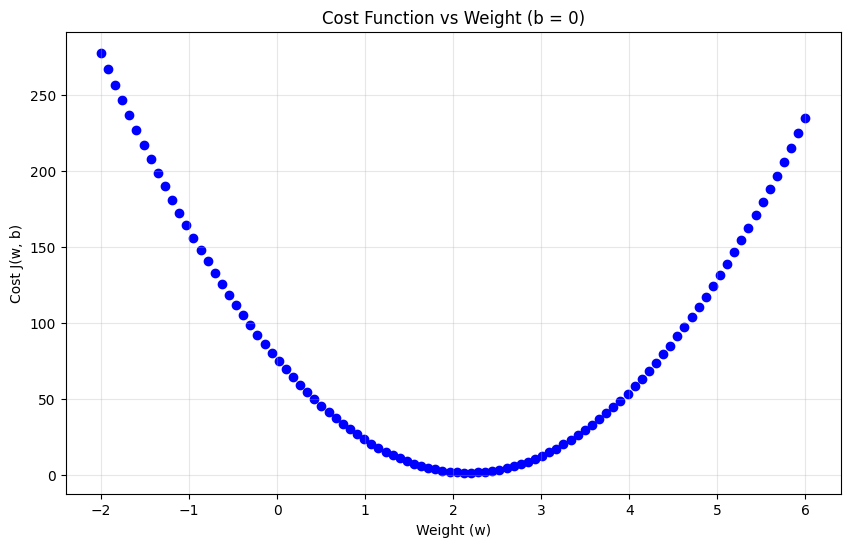

In [39]:

# Visualize cost function for different w values (keeping b = 0)
w_range = np.linspace(-2, 6, 100)
predictions = [hypothesis(X_train, w, 0) for w in w_range]
costs = [compute_cost(pred, y_train) for pred in predictions]

plt.figure(figsize=(10, 6))
plt.scatter(w_range, costs, c= 'b')
plt.xlabel('Weight (w)')
plt.ylabel('Cost J(w, b)')
plt.title('Cost Function vs Weight (b = 0)')
plt.grid(True, alpha=0.3)
plt.show()


# Understanding Gradient Descent

## What is Gradient Descent?

**Gradient Descent** is an optimization algorithm used to minimize the cost function by iteratively adjusting the parameters in the direction of steepest descent.

## How Gradient Descent Works

1. **Start** with initial parameter values (w, b)
2. **Calculate** the gradient (partial derivatives)
3. **Update** parameters in the opposite direction of gradient
4. **Repeat** until convergence

# Mathematical Formulation

## Partial Derivatives:
$$∂J/∂w = \frac{1}{m} \sum_{i=1}^{m} \left( f(x^{i}) - y^{i} \right) x^{i}$$
$$∂J/∂b = \frac{1}{m} \sum_{i=1}^{m} \left( f(x^{i}) - y^{i} \right)$$


In [40]:
# Function 3: Gradient Calculation (Non-vectorized)
def compute_gradients(X, y, predictions):
    m = len(y)
    
    sum_grad_w = 0
    sum_grad_b = 0
    for i in range(m):
        sum_grad_w = sum_grad_w + (predictions[i] - y[i]) * X[i]
        sum_grad_b = sum_grad_b + predictions[i] - y[i]

    # Calculate gradients
    grad_w = (1/m) * sum_grad_w
    grad_b = (1/m) * sum_grad_b

    return grad_w, grad_b

In [41]:
test_w, test_b = 1, 2
pred = hypothesis(X_train, test_w, test_b)
grad_w, grad_b = compute_gradients(pred, X_train, y_train)

print(f"Parameters: w = {test_w}, b = {test_b}")
print(f"Gradient w: {grad_w:.4f}")
print(f"Gradient b: {grad_b:.4f}")


Parameters: w = 1, b = 2
Gradient w: 49.0756
Gradient b: 5.9516


In [42]:
# Test with different parameters
test_params = [(0, 0), (1, 1), (2, 2), (3, 1)]
print(f"\nGradients for different parameters:")
for w, b in test_params:
    pred = hypothesis(X_train, w, b)
    grad_w, grad_b = compute_gradients(X_train, y_train, pred)
    print(f"w = {w}, b = {b} → grad_w = {grad_w:.4f}, grad_b = {grad_b:.4f}")



Gradients for different parameters:
w = 0, b = 0 → grad_w = -68.9417, grad_b = -10.8464
w = 1, b = 1 → grad_w = -32.2776, grad_b = -4.9516
w = 2, b = 2 → grad_w = 4.3865, grad_b = 0.9432
w = 3, b = 1 → grad_w = 31.2610, grad_b = 4.8380


## Parameter Updates:
$$
w = w - \alpha \frac{\partial J}{\partial w}
$$
$$
b = b - \alpha \frac{\partial J}{\partial b}
$$

Where $\alpha$ is the learning rate.

## Learning Rate Importance

- **Too small**: Slow convergence
- **Too large**: May overshoot the minimum
- **Just right**: Efficient convergence

In [43]:
def update_parameters(w, b, grad_w, grad_b, lr):

    new_w = w - lr * grad_w
    new_b = b - lr * grad_b

    return new_w, new_b


In [44]:
# Complete Gradient Descent Algorithm
def gradient_descent(
    X, y, learning_rate=0.01, epochs=1000, verbose=True
):
    # Initialize parameters
    w, b = np.random.randn(), np.random.randn()
    m = len(X)

    # Store history for visualization
    cost_history = []
    w_history = []
    b_history = []

    if verbose:
        print(f"Starting Gradient Descent...")
        print(f"Learning rate: {learning_rate}")
        print(f"Number of iterations: {epochs}")
        print(f"Training examples: {m}")
        print("-" * 50)

    for i in range(epochs):
        # Calculate current cost
        pred = hypothesis(X, w, b)
        current_cost = compute_cost(pred, y)
        cost_history.append(current_cost)
        w_history.append(w)
        b_history.append(b)

        # Calculate gradients
        grad_w, grad_b = compute_gradients(X, y, pred)

        # Update parameters
        w, b = update_parameters(w, b, grad_w, grad_b, learning_rate)

        # Print progress every 100 iterations
        if verbose and (i + 1) % 10 == 0:
            print(
                f"Iteration {i+1:4d}: Cost = {current_cost:.6f}, w = {w:.4f}, b = {b:.4f}"
            )

    if verbose:
        print("-" * 50)
        print(f"Final parameters: w = {w:.4f}, b = {b:.4f}")
        print(f"Final cost: {cost_history[-1]:.6f}")

    return w, b, cost_history, w_history, b_history


In [46]:
w_final, b_final, cost_history, w_history, b_history = (
    gradient_descent(
        X_train, y_train, learning_rate = 0.01, epochs = 500
    )
)

print("Gradient descent completed successfully!")

Starting Gradient Descent...
Learning rate: 0.01
Number of iterations: 500
Training examples: 160
--------------------------------------------------
Iteration   10: Cost = 1.820468, w = 1.7383, b = 2.4008
Iteration   20: Cost = 1.681225, w = 1.8014, b = 2.3742
Iteration   30: Cost = 1.668782, w = 1.8079, b = 2.3397
Iteration   40: Cost = 1.656970, w = 1.8132, b = 2.3058
Iteration   50: Cost = 1.645712, w = 1.8183, b = 2.2727
Iteration   60: Cost = 1.634982, w = 1.8233, b = 2.2404
Iteration   70: Cost = 1.624757, w = 1.8282, b = 2.2088
Iteration   80: Cost = 1.615011, w = 1.8330, b = 2.1780
Iteration   90: Cost = 1.605723, w = 1.8377, b = 2.1480
Iteration  100: Cost = 1.596870, w = 1.8422, b = 2.1186
Iteration  110: Cost = 1.588433, w = 1.8467, b = 2.0900
Iteration  120: Cost = 1.580393, w = 1.8510, b = 2.0620
Iteration  130: Cost = 1.572729, w = 1.8553, b = 2.0347
Iteration  140: Cost = 1.565426, w = 1.8594, b = 2.0080
Iteration  150: Cost = 1.558465, w = 1.8634, b = 1.9820
Iteration  

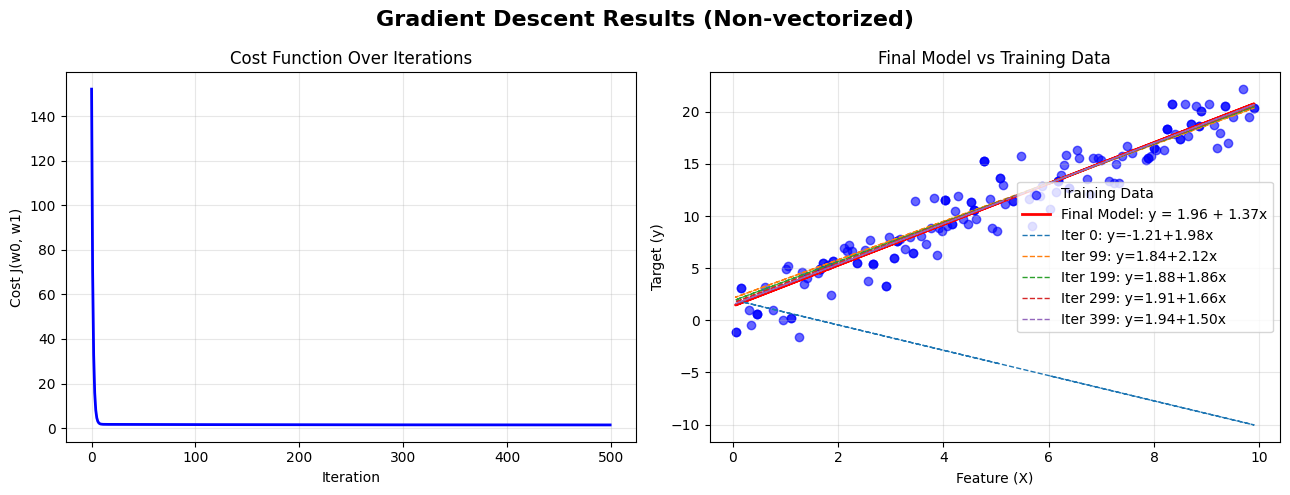

In [49]:
# Create comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gradient Descent Results (Non-vectorized)', fontsize=16, fontweight='bold')

# Plot 1: Cost function over iterations
axes[0].plot(cost_history, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost J(w0, w1)')
axes[0].set_title('Cost Function Over Iterations')
axes[0].grid(True, alpha=0.3)

# Plot 2: Final model vs data
# x_range = np.linspace(X_train.min(), X_train.max(), 100)
x_range = X_train
y_pred = hypothesis(x_range,w_final, b_final)

axes[1].scatter(X_train, y_train, alpha=0.6, color='blue', label='Training Data')
axes[1].plot(x_range, y_pred, 'r-', linewidth=2, label=f'Final Model: y = {w_final:.2f} + {b_final:.2f}x')
# Plot 5 lines before the final weights are achieved
for idx in np.linspace(0, len(w_history)-1, 6, dtype=int)[:-1]:
    y_pred_hist = hypothesis(x_range,w_history[idx], b_history[idx])
    axes[1].plot(x_range, y_pred_hist, '--', alpha=1, linewidth=1,
                 label=f'Iter {idx}: y={w_history[idx]:.2f}+{b_history[idx]:.2f}x')

axes[1].set_xlabel('Feature (X)')
axes[1].set_ylabel('Target (y)')
axes[1].set_title('Final Model vs Training Data')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [50]:

# Evaluate model performance
train_predictions = hypothesis( X_train ,w_final, b_final)
test_predictions = hypothesis( X_test, w_final, b_final)

train_mse = np.mean((train_predictions - y_train) ** 2)
test_mse = np.mean((test_predictions - y_test) ** 2)

print(f"\nModel Performance:")
print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Final parameters: w = {w_final:.4f}, b = {b_final:.4f}")
print(f"Final cost: {cost_history[-1]:.6f}")



Model Performance:
Training MSE: 2.8866
Testing MSE: 2.0624
Final parameters: w = 1.9579, b = 1.3736
Final cost: 1.443406


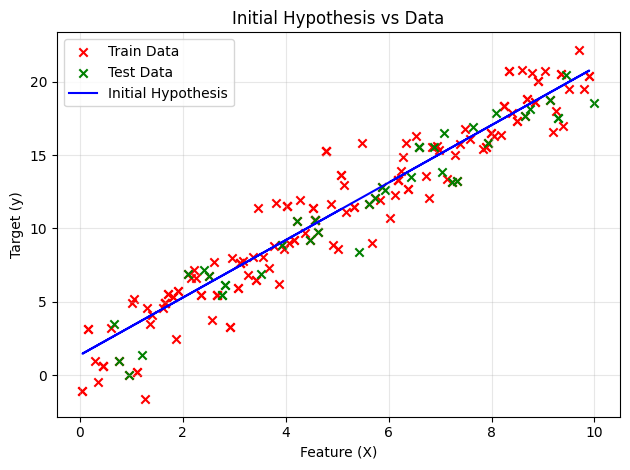

In [51]:
# Visualize final predictions vs actual data

plt.scatter(X_train, y_train, label="Train Data", marker='x', c = 'red')
plt.scatter(X_test, y_test, label="Test Data", marker='x', c = 'green')
plt.plot(X_train, train_predictions, color='blue', label="Initial Hypothesis")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Initial Hypothesis vs Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Vectorized Implementation

## Why Vectorization?

**Vectorization** uses matrix operations instead of loops, making computations much faster and more efficient.

We'll use Class to create Regression Model


In [54]:
from IPython import display
class LinearRegression:
    def __init__(self, learning_rate = 0.01, epochs = 1000, verbose = True):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.verbose = verbose
        self.w = np.random.randn()
        self.b = np.random.randn()

    @staticmethod
    def hypothesis(X, w, b):
        return w * X + b
    
    @staticmethod
    def compute_cost(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2) / 2

    @staticmethod
    def compute_gradients(X, y_true, y_pred):
        m = len(y_true)
        grad_w = (1/m) * np.sum((y_pred - y_true) * X)
        grad_b = (1/m) * np.sum(y_pred - y_true)
        return grad_w, grad_b
    
    @staticmethod
    def update_parameters(w, b, grad_w, grad_b, lr):
        new_w = w - lr * grad_w
        new_b = b - lr * grad_b
        return new_w, new_b
    
    def fit(self, X, y):
        m = len(X)
        cost_history = []

        for i in range(self.epochs):
            preds = self.hypothesis(X, self.w, self.b)
            cost = self.compute_cost(y, preds)
            grad_w, grad_b = self.compute_gradients(X, y, preds)
            self.w, self.b = self.update_parameters(self.w, self.b, grad_w, grad_b, self.learning_rate)

            # Print progress every 100 iterations
            if self.verbose and (i + 1) % 10 == 0:
                display.clear_output(wait=True)

                
                plt.figure(figsize=(8, 5))
                plt.scatter(X, y, color='blue', label='Data', marker='x')
                plt.plot(X, self.hypothesis(X, self.w, self.b), color='red', label='Regression Line')
                plt.title(f"Iteration {i+1} | Cost: {cost:.6f} | w: {self.w:.4f}, b: {self.b:.4f}")
                plt.legend()
                plt.show()
                plt.close() # Close the plot to prevent too many open figures

    def predict(self, X):
        return self.hypothesis(X, self.w, self.b)

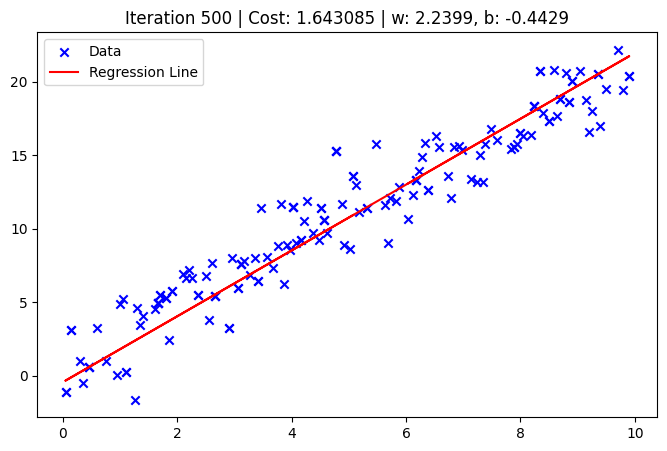

In [61]:

model = LinearRegression(learning_rate=0.001, epochs=500, verbose=True)
model.fit(X_train, y_train)

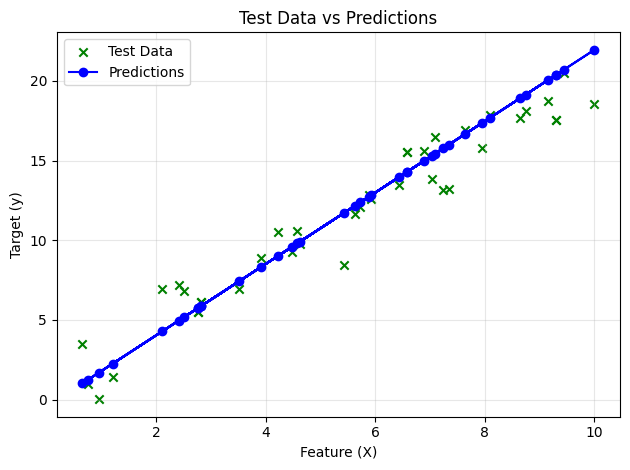

In [62]:
predictions = model.predict(X_test)
plt.scatter(X_test, y_test, label="Test Data", marker='x', c = 'green')
plt.plot(X_test, predictions, c = 'blue', label = 'Predictions', marker='o')
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Test Data vs Predictions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from IPython import display
class LinearRegression:
    def __init__(self, learning_rate = 0.01, epochs = 1000, verbose = True):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.verbose = verbose
        self.w = np.random.randn()
        self.b = np.random.randn()

    @staticmethod
    def hypothesis(X, w, b):
        return w * X + b
    
    @staticmethod
    def compute_cost(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2) / 2

    @staticmethod
    def compute_gradients(X, y_true, y_pred):
        m = len(y_true)
        grad_w = (1/m) * np.sum((y_pred - y_true) * X)
        grad_b = (1/m) * np.sum(y_pred - y_true)
        return grad_w, grad_b
    
    @staticmethod
    def update_parameters(w, b, grad_w, grad_b, lr):
        new_w = w - lr * grad_w
        new_b = b - lr * grad_b
        return new_w, new_b
    
    def fit(self, X, y):
        self.cost_history = []
        self.w_history = []
        self.b_history = []

        for i in range(self.epochs):

            preds = self.hypothesis(X, self.w, self.b)
            cost = self.compute_cost(y, preds)
            
            self.cost_history.append(cost)
            self.w_history.append(self.w)
            self.b_history.append(self.b)
            
            grad_w, grad_b = self.compute_gradients(X, y, preds)
            self.w, self.b = self.update_parameters(self.w, self.b, grad_w, grad_b, self.learning_rate)

            if self.verbose and (i + 1) % 10 == 0:
                display.clear_output(wait=True)
                fig, axes = plt.subplots(1, 4, figsize=(22, 7))

                # --- Plot 1: Cost vs w ---
                axes[0].plot(self.w_history, self.cost_history, color='red', marker='o')
                axes[0].set_title("Path of w vs Cost")
                axes[0].set_xlabel("w")
                axes[0].set_ylabel("Cost")
                # Expand limits slightly so the points aren't touching the edge
                axes[0].set_xlim(min(self.w_history) - 0.5, max(self.w_history) + 0.5)
                axes[0].set_ylim(min(self.cost_history) * 0.9, max(self.cost_history) * 1.1)

                # --- Plot 2: Cost vs b  ---
                axes[1].plot(self.b_history, self.cost_history, color='green', marker='o')
                axes[1].set_title("Path of b vs Cost")
                axes[1].set_xlabel("b")
                axes[1].set_xlim(min(self.b_history) - 0.5, max(self.b_history) + 0.5)
                axes[1].set_ylim(min(self.cost_history) * 0.9, max(self.cost_history) * 1.1)
                
                # --- Plot 3: Learning Curve ---
                axes[2].plot(range(len(self.cost_history)), self.cost_history, color='purple')
                axes[2].set_title("Cost vs Iteration")
                axes[2].set_xlabel("Iteration")
                # The x-axis here grows naturally with the loop index

                # --- Plot 4: Regression Fit ---
                axes[3].scatter(X, y, color='blue', marker='x', alpha=0.5, label="Data")
                axes[3].plot(X, self.hypothesis(X, self.w, self.b), color='red', lw=2, label="Model")
                axes[3].set_title(f"Iteration {i+1}")
                axes[3].legend()

                plt.tight_layout()
                plt.show()
                plt.close(fig)

    def predict(self, X):
        return self.hypothesis(X, self.w, self.b)

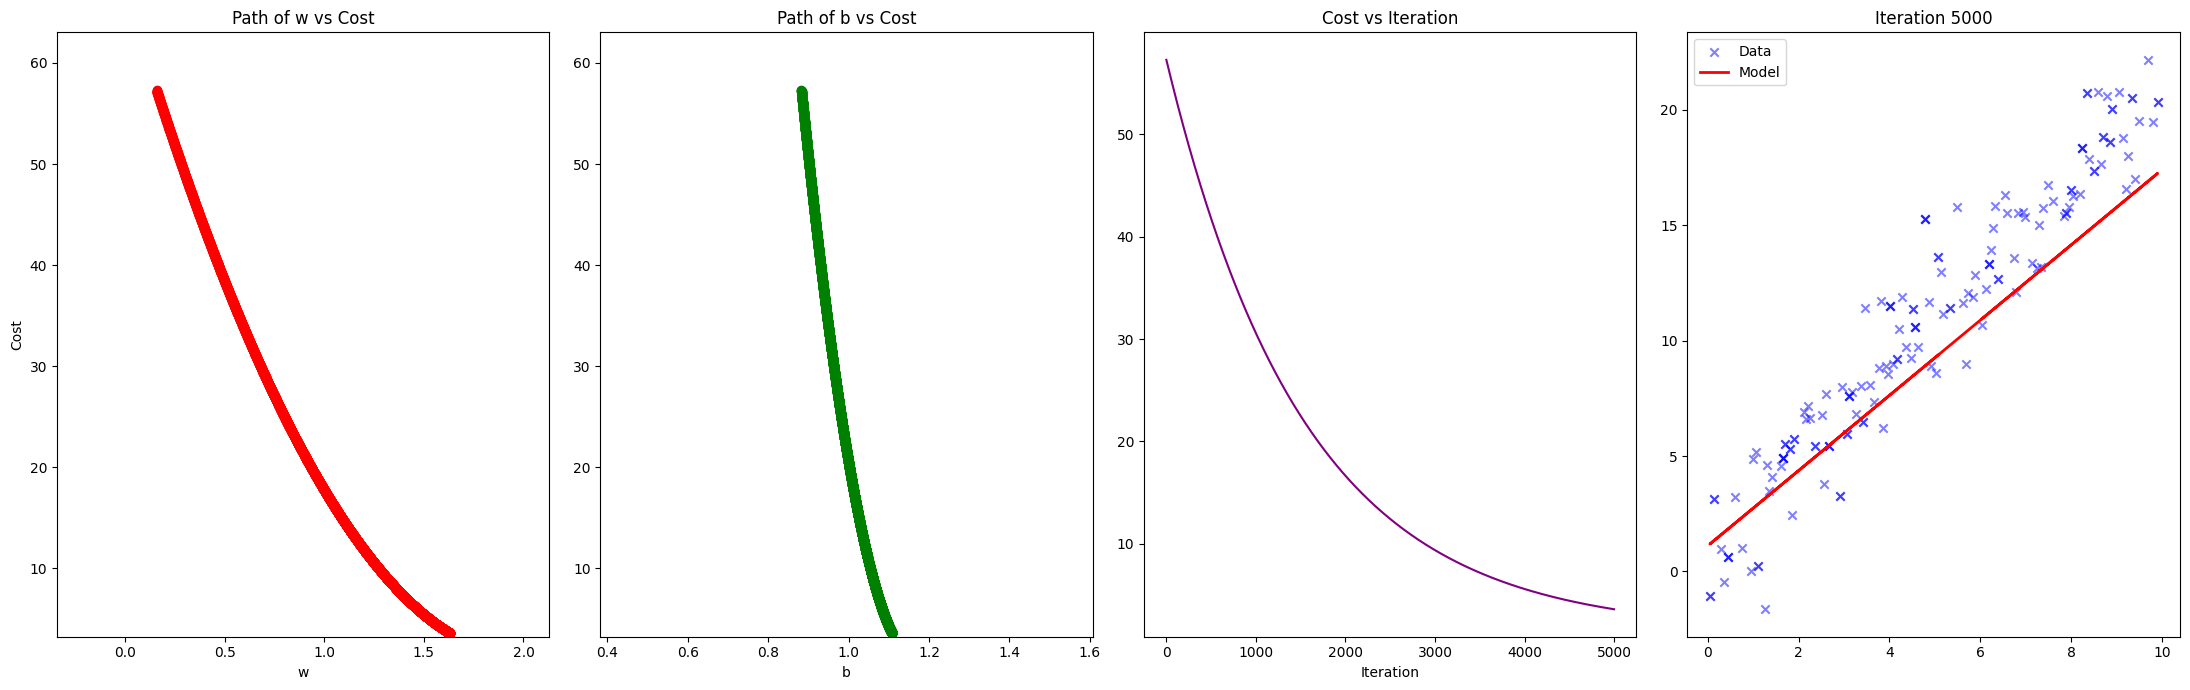

In [67]:
model = LinearRegression(learning_rate=0.00001, epochs=5000, verbose=True)
model.fit(X_train, y_train)

## Linear Regression Using Scikit-Learn

In [63]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train.reshape(-1, 1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
model.coef_, model.intercept_

(array([2.0673281]), np.float64(0.684147627993104))

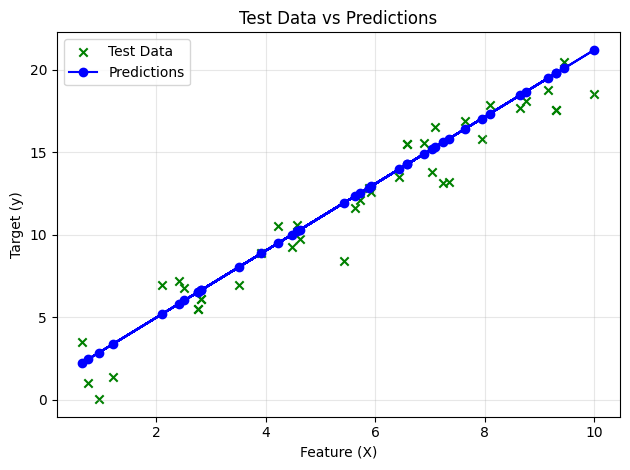

In [64]:
predictions = model.predict(X_test.reshape(-1, 1))

plt.scatter(X_test, y_test, label="Test Data", marker='x', c = 'green')
plt.plot(X_test, predictions, c = 'blue', label = 'Predictions', marker='o')
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Test Data vs Predictions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()